# 04 — Analytics Insights


## 1. Purpose and scope


This notebook reviews descriptive metrics produced by the funnel and LTV-proxy marts.

**Logic chain:** load marts → summarise daily funnel → compare segments → inspect associations → state evidence limits.

All records are synthetic and cover only 1–7 October 2025. Results are portfolio demonstrations, not findings about a real business. The `ltv` field represents observed paid revenue per registered user during this short period; it is not a lifetime-value forecast.


## 2. Mart data overview


The analysis uses three PostgreSQL mart tables:

- `marts.fact_daily_funnel`
- `marts.fact_ltv`
- `marts.fact_segment_funnel`

The first two are loaded below; the segment funnel is loaded when the cross-analysis begins.


In [ ]:
from pathlib import Path
import os

import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import URL, create_engine


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".env.example").exists() and (candidate / "dw" / "marts").exists():
            return candidate
    raise FileNotFoundError("Project root could not be located.")


PROJECT_ROOT = find_project_root()
load_dotenv(PROJECT_ROOT / ".env")

if not os.getenv("PGPASSWORD"):
    raise RuntimeError("Set PGPASSWORD in the local .env file before running this notebook.")

database_url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("PGUSER", "postgres"),
    password=os.getenv("PGPASSWORD"),
    host=os.getenv("PGHOST", "localhost"),
    port=int(os.getenv("PGPORT", "5432")),
    database=os.getenv("PGDATABASE", "customer_analytics_dw"),
)
engine = create_engine(database_url)

funnel_query = """
SELECT *
FROM marts.fact_daily_funnel
ORDER BY date;
"""

ltv_query = """
SELECT *
FROM marts.fact_ltv;
"""

df_funnel = pd.read_sql_query(funnel_query, engine)
df_ltv = pd.read_sql_query(ltv_query, engine)


In [2]:
df_funnel.head()

,date,view_users,click_users,purchase_users,view_to_click_rate,click_to_purchase_rate,overall_conversion_rate
0,2025-10-01,544,223,44,0.4099,0.1973,0.0809
1,2025-10-02,535,213,34,0.3981,0.1596,0.0636
2,2025-10-03,527,195,34,0.3700,0.1744,0.0645
3,2025-10-04,410,145,22,0.3537,0.1517,0.0537
4,2025-10-05,411,176,29,0.4282,0.1648,0.0706


In [3]:
df_ltv.head()

,registration_month,region,age_group,total_users,total_revenue,ltv
0,2025-06-01,ACT,18-24,2,0.00,0.00
1,2025-06-01,ACT,25-34,8,0.00,0.00
2,2025-06-01,ACT,35-44,2,0.00,0.00
3,2025-06-01,ACT,45-54,5,59.79,11.96
4,2025-06-01,ACT,55-64,2,0.00,0.00


## 3. Funnel analysis


### 3.1 Period-level stage summary


Daily distinct-user counts are summed to describe total **daily stage observations** across the seven dates. A user active on multiple days can therefore contribute more than once; these totals are not period-level unique-user counts.


#### Step 1 — Aggregate daily stage observations


In [4]:
total_views = df_funnel["view_users"].sum()
total_clicks = df_funnel["click_users"].sum()
total_purchases = df_funnel["purchase_users"].sum()

print(f"Sum of daily unique view users: {total_views:,}")
print(f"Sum of daily unique click users: {total_clicks:,}")
print(f"Sum of daily unique paid-purchase users: {total_purchases:,}")


Sum of daily unique view users: 3,515
Sum of daily unique click users: 1,383
Sum of daily unique paid-purchase users: 253


#### Step 2 — Calculate weighted period ratios


In [5]:
view_to_click = total_clicks / total_views
click_to_purchase = total_purchases / total_clicks
overall_conversion = total_purchases / total_views

print(f"Weighted view-to-click ratio: {view_to_click:.2%}")
print(f"Weighted click-to-purchase ratio: {click_to_purchase:.2%}")
print(f"Weighted overall conversion ratio: {overall_conversion:.2%}")


Weighted view-to-click ratio: 39.35%
Weighted click-to-purchase ratio: 18.29%
Weighted overall conversion ratio: 7.20%


#### Step 3 — Build the stage summary


In [6]:
funnel_summary = pd.DataFrame({
    "stage": ["View", "Click", "Purchase"],
    "users": [total_views, total_clicks, total_purchases]
})

funnel_summary

,stage,users
0,View,3515
1,Click,1383
2,Purchase,253


#### Step 4 — Visualise stage observations


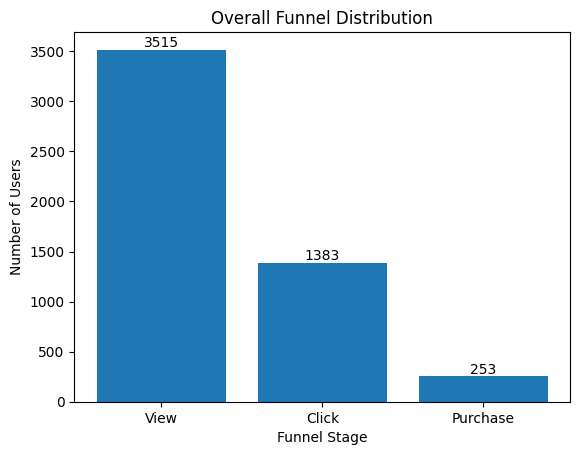

In [7]:
import matplotlib.pyplot as plt

bars = plt.bar(funnel_summary["stage"], funnel_summary["users"])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom'
    )

plt.title("Overall Funnel Distribution")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Users")
plt.show()

#### Step 5 — Display conversion ratios


In [8]:
conversion_summary = pd.DataFrame({
    "metric": [
        "View to Click Rate",
        "Click to Purchase Rate",
        "Overall Conversion Rate"
    ],
    "value": [
        view_to_click,
        click_to_purchase,
        overall_conversion
    ]
})

conversion_summary

,metric,value
0,View to Click Rate,0.393457
1,Click to Purchase Rate,0.182936
2,Overall Conversion Rate,0.071977


#### Findings

- The supplied sample contains fewer daily click-user observations than view-user observations.
- Paid-purchase-user observations are the smallest stage.
- The period ratios describe this generated sample only; they do not identify why users did or did not progress.


### 3.2 Daily funnel trend


Daily stage counts are compared across the seven observed dates to identify descriptive variation in the generated sample.


#### Step 1 — Prepare dates


In [9]:
df_funnel["date"] = pd.to_datetime(df_funnel["date"])

#### Step 2 — Plot daily stage counts


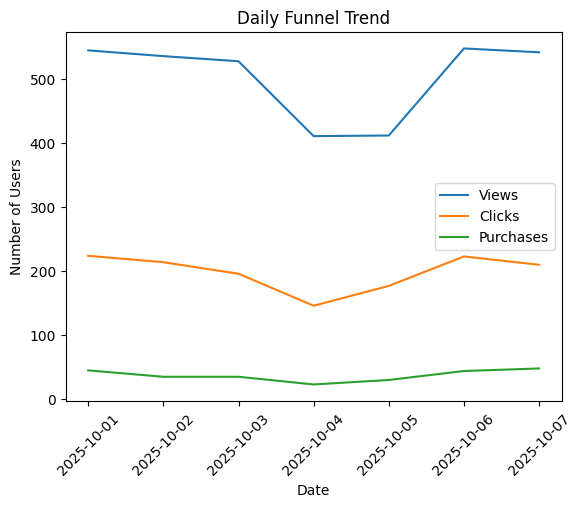

In [10]:
plt.figure()

plt.plot(df_funnel["date"], df_funnel["view_users"], label="Views")
plt.plot(df_funnel["date"], df_funnel["click_users"], label="Clicks")
plt.plot(df_funnel["date"], df_funnel["purchase_users"], label="Purchases")

plt.title("Daily Funnel Trend")
plt.xlabel("Date")
plt.ylabel("Number of Users")

plt.legend()
plt.xticks(rotation=45)

plt.show()

#### Findings

- Views, clicks, and paid purchases move broadly in the same direction across the seven dates.
- 4 October has the lowest activity in the supplied period.
- Seven observations are not enough to establish seasonality, trends, or operational causes.


#### Step 3 — Plot daily conversion ratios


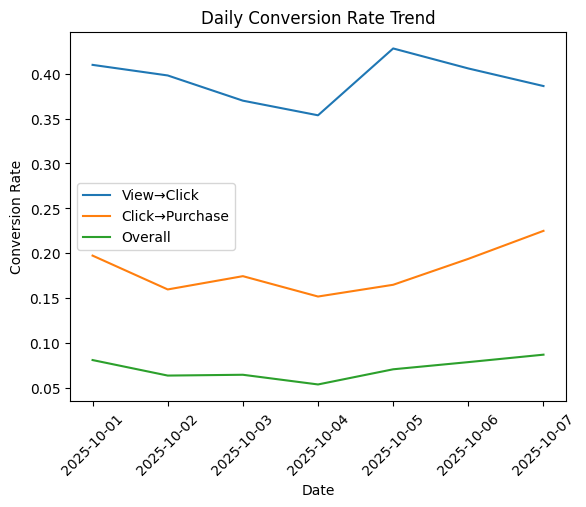

In [11]:
plt.figure()

plt.plot(df_funnel["date"], df_funnel["view_to_click_rate"], label="View→Click")
plt.plot(df_funnel["date"], df_funnel["click_to_purchase_rate"], label="Click→Purchase")
plt.plot(df_funnel["date"], df_funnel["overall_conversion_rate"], label="Overall")

plt.title("Daily Conversion Rate Trend")
plt.xlabel("Date")
plt.ylabel("Conversion Rate")

plt.legend()
plt.xticks(rotation=45)

plt.show()

#### Findings

- View-to-click ratios remain within a relatively narrow range in this generated week.
- Click-to-purchase ratios vary more because the final-stage counts are smaller.
- Any explanation involving pricing, promotions, user experience, or traffic quality would require additional evidence.


### 3.3 Average daily conversion ratios


The next comparison uses the unweighted mean of the seven daily ratios. It complements, but is not identical to, the ratio calculated from summed daily counts.


#### Step 1 — Calculate daily means


In [12]:
avg_view_to_click = df_funnel["view_to_click_rate"].mean()
avg_click_to_purchase = df_funnel["click_to_purchase_rate"].mean()
avg_overall = df_funnel["overall_conversion_rate"].mean()

avg_view_to_click, avg_click_to_purchase, avg_overall

(np.float64(0.3931571428571428),
 np.float64(0.18091428571428572),
 np.float64(0.07125714285714287))

#### Step 2 — Build the comparison table


In [13]:
conversion_comparison = pd.DataFrame({
    "stage": [
        "View -> Click",
        "Click -> Purchase",
        "Overall"
    ],
    "conversion_rate": [
        avg_view_to_click,
        avg_click_to_purchase,
        avg_overall
    ]
})

conversion_comparison

,stage,conversion_rate
0,View -> Click,0.393157
1,Click -> Purchase,0.180914
2,Overall,0.071257


#### Step 3 — Visualise the comparison


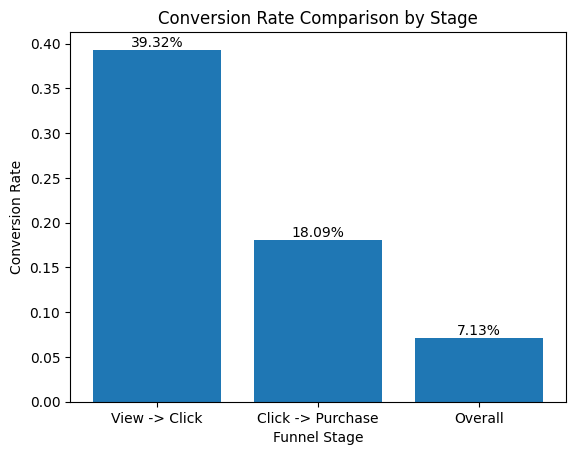

In [14]:
plt.figure()

bars = plt.bar(
    conversion_comparison["stage"],
    conversion_comparison["conversion_rate"]
)

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2%}",
        ha='center',
        va='bottom'
    )

plt.title("Conversion Rate Comparison by Stage")
plt.xlabel("Funnel Stage")
plt.ylabel("Conversion Rate")

plt.show()

#### Finding

The click-to-purchase stage has the lower average daily ratio in this sample. This identifies where additional real-world investigation could begin; it does not demonstrate checkout friction or another specific cause.


### 3.4 Descriptive stage drop-off


This section expresses the difference between summed daily stage observations as counts and rates. It is a descriptive comparison, not user-level path analysis across the full period.


#### Step 1 — Calculate stage differences


In [15]:
views = df_funnel["view_users"].sum()
clicks = df_funnel["click_users"].sum()
purchases = df_funnel["purchase_users"].sum()

drop_view_to_click = views - clicks
drop_click_to_purchase = clicks - purchases

drop_rate_view_to_click = drop_view_to_click / views
drop_rate_click_to_purchase = drop_click_to_purchase / clicks

print(f"View-to-click observation difference: {drop_rate_view_to_click:.2%}")
print(f"Click-to-purchase observation difference: {drop_rate_click_to_purchase:.2%}")


The drop-off rate of view-to-click stage: ==== 0.6065433854907539 ====
The drop-off rate of click-to-purchase stage: ==== 0.8170643528561099 ====


#### Step 2 — Build the drop-off table


In [16]:
dropoff_summary = pd.DataFrame({
    "stage": [
        "View → Click",
        "Click → Purchase"
    ],
    "dropoff_users": [
        drop_view_to_click,
        drop_click_to_purchase
    ],
    "dropoff_rate": [
        drop_rate_view_to_click,
        drop_rate_click_to_purchase
    ]
})

dropoff_summary

,stage,dropoff_users,dropoff_rate
0,View → Click,2132,0.606543
1,Click → Purchase,1130,0.817064


#### Step 3 — Visualise stage differences


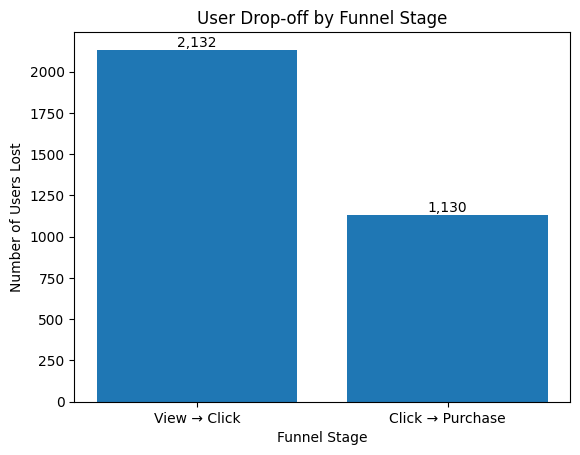

In [17]:
plt.figure()

bars = plt.bar(
    dropoff_summary["stage"],
    dropoff_summary["dropoff_users"]
)

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha='center',
        va='bottom'
    )

plt.title("User Drop-off by Funnel Stage")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Users Lost")

plt.show()

#### Findings

- The largest absolute difference occurs between view and click observations.
- The final-stage rate remains lower than the top-of-funnel rate.
- A real diagnosis would require session paths, experiment data, and information about product or checkout conditions.


## 4. Observed-period revenue per user (LTV proxy)


### 4.1 Definition


The mart divides paid revenue observed in the seven-day source period by all registered users in each cohort and segment. The notebook uses the shorter label `LTV`, but all interpretations treat it as an observed-period proxy.


### 4.2 LTV proxy by region


Weighted revenue per registered user is compared across synthetic regions. Differences are descriptive and may reflect generated sample composition.


#### Step 1 — Aggregate by region


In [18]:
region_ltv = (
    df_ltv
    .groupby("region")
    .agg({
        "total_users": "sum",
        "total_revenue": "sum"
    })
    .reset_index()

)

# Calculate weighted LTV
region_ltv["ltv"] = region_ltv["total_revenue"] / region_ltv["total_users"]

region_ltv

,region,total_users,total_revenue,ltv
0,ACT,67,473.75,7.070896
1,NSW,995,5094.06,5.119658
2,NT,64,258.33,4.036406
3,QLD,489,3741.80,7.651943
4,SA,202,1596.22,7.902079
5,TAS,115,643.21,5.593130
6,VIC,773,5108.07,6.608111
7,WA,295,2407.85,8.162203


#### Step 2 — Visualise regional values


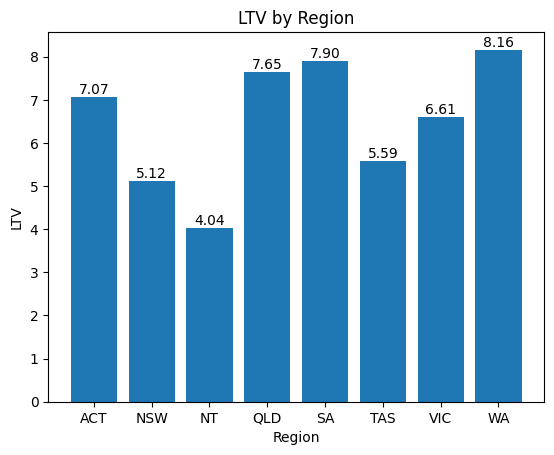

In [19]:
plt.figure()

bars = plt.bar(region_ltv["region"], region_ltv["ltv"])

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom'
    )

plt.title("LTV by Region")
plt.xlabel("Region")
plt.ylabel("LTV")

plt.show()

#### Finding

Observed revenue per registered user varies across the eight synthetic regions. This supports a segmentation example, but it is not evidence of purchasing power, market fit, or marketing effectiveness.


### 4.3 LTV proxy by age group


Weighted revenue per registered user is compared across the six synthetic age groups.


#### Step 1 — Aggregate by age group


In [20]:
age_ltv = (
    df_ltv
    .groupby("age_group")
    .agg({
        "total_users": "sum",
        "total_revenue": "sum"
    })
    .reset_index()
)

# Calculate weighted LTV
age_ltv["ltv"] = age_ltv["total_revenue"] / age_ltv["total_users"]

age_ltv

,age_group,total_users,total_revenue,ltv
0,18-24,488,3762.94,7.710943
1,25-34,890,5367.01,6.030348
2,35-44,651,3665.86,5.631121
3,45-54,497,3302.92,6.645714
4,55-64,315,2233.98,7.092000
5,65+,159,990.58,6.230063


#### Step 2 — Visualise age-group values


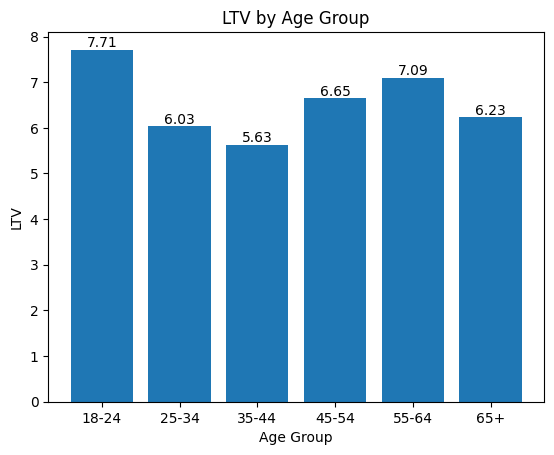

In [21]:
plt.figure()

bars = plt.bar(age_ltv["age_group"], age_ltv["ltv"])

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom'
    )

plt.title("LTV by Age Group")
plt.xlabel("Age Group")
plt.ylabel("LTV")

plt.show()

#### Finding

Age-group values differ in the generated sample, but the short period does not support demographic targeting claims or conclusions about underlying behaviour.


### 4.4 LTV proxy by registration cohort


Registration-month cohorts are compared using the same weighted observed-revenue measure.


#### Step 1 — Aggregate by registration month


In [22]:
cohort_ltv = (
    df_ltv
    .groupby("registration_month")
    .agg({
        "total_users": "sum",
        "total_revenue": "sum"
    })
    .reset_index()
)

# Calculate weighted LTV
cohort_ltv["ltv"] = cohort_ltv["total_revenue"] / cohort_ltv["total_users"]

cohort_ltv

,registration_month,total_users,total_revenue,ltv
0,2025-06-01,762,5397.74,7.083648
1,2025-07-01,760,4785.89,6.297224
2,2025-08-01,726,4702.52,6.477300
3,2025-09-01,752,4437.14,5.900452


#### Step 2 — Visualise cohort values


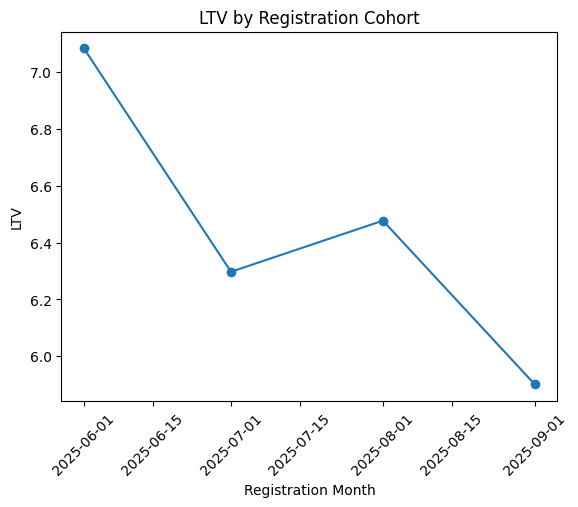

In [23]:
plt.figure()

plt.plot(cohort_ltv["registration_month"], cohort_ltv["ltv"], marker='o')

plt.title("LTV by Registration Cohort")
plt.xlabel("Registration Month")
plt.ylabel("LTV")

plt.xticks(rotation=45)

plt.show()

#### Finding

Cohort values vary across June–September 2025. Because every cohort is observed during the same seven order dates but has a different age, this simple comparison should not be interpreted as a controlled acquisition-quality or retention analysis.


### 4.5 LTV proxy by region and age group


Combined region and age-group segments provide a more detailed descriptive view, while also creating smaller samples and less stable values.


#### Step 1 — Query segment values


In [24]:
query_segment_ltv = """
SELECT
    region,
    age_group,
    SUM(total_users) AS total_users,
    SUM(total_revenue) AS total_revenue,
    ROUND(SUM(total_revenue) / SUM(total_users), 2) AS ltv
FROM marts.fact_ltv
GROUP BY region, age_group
ORDER BY ltv DESC;
"""

df_segment_ltv = pd.read_sql_query(query_segment_ltv, engine)
df_segment_ltv.head(10)

,region,age_group,total_users,total_revenue,ltv
0,ACT,35-44,9.0,255.86,28.43
1,WA,65+,17.0,258.58,15.21
2,TAS,35-44,36.0,514.69,14.30
3,SA,65+,13.0,175.68,13.51
4,QLD,45-54,90.0,1201.62,13.35
5,NT,55-64,6.0,78.13,13.02
6,SA,18-24,31.0,388.22,12.52
7,SA,25-34,63.0,685.08,10.87
8,QLD,18-24,85.0,869.51,10.23
9,WA,55-64,31.0,310.73,10.02


In [25]:
pivot_segment_ltv = df_segment_ltv.pivot(
    index='age_group',
    columns='region',
    values='ltv'
)

pivot_segment_ltv

region,ACT,NSW,NT,QLD,SA,TAS,VIC,WA
age_group,,,,,,,,
18-24,4.32,5.30,2.37,10.23,12.52,3.95,9.52,7.85
25-34,4.81,4.74,2.74,5.08,10.87,1.24,6.86,8.45
35-44,28.43,4.14,6.23,7.25,0.00,14.30,4.49,5.59
45-54,5.44,4.98,0.00,13.35,5.11,0.00,5.15,7.64
55-64,0.00,7.09,13.02,2.82,7.43,0.00,9.57,10.02
65+,0.00,7.11,0.00,2.82,13.51,0.00,2.79,15.21


#### Step 2 — Visualise segment values


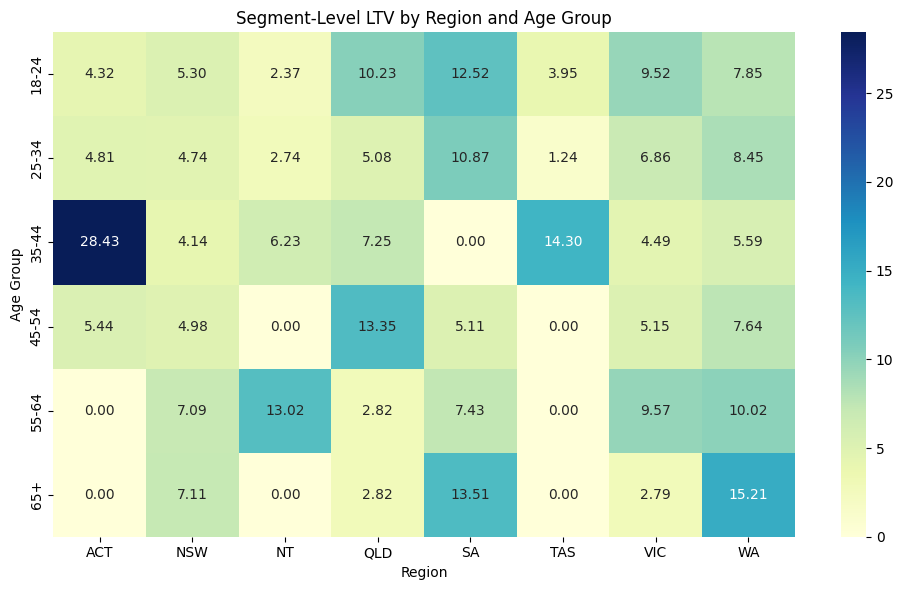

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_segment_ltv, annot=True, fmt=".2f", cmap="YlGnBu")

plt.title("Segment-Level LTV by Region and Age Group")
plt.xlabel("Region")
plt.ylabel("Age Group")
plt.tight_layout()
plt.show()

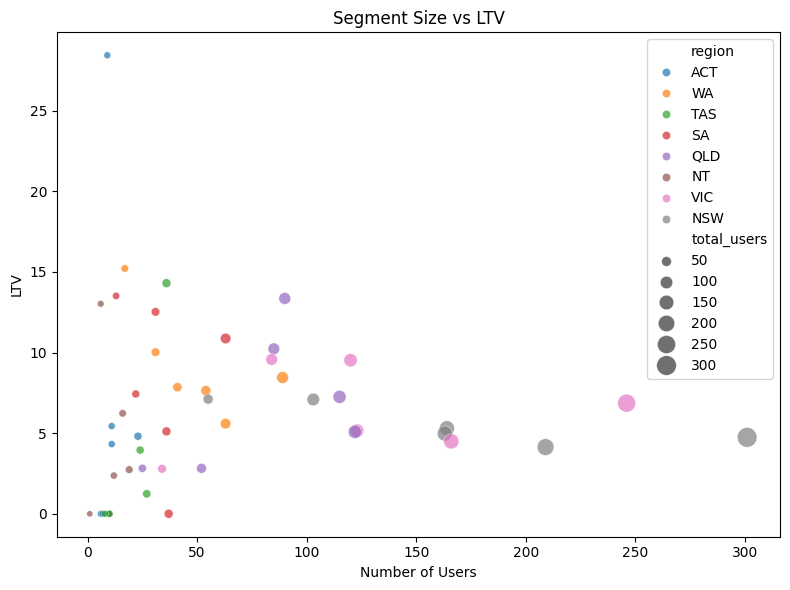

In [27]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_segment_ltv,
    x="total_users",   
    y="ltv",
    hue="region",
    size="total_users",  
    sizes=(20, 200),
    alpha=0.7
)

plt.title("Segment Size vs LTV")
plt.xlabel("Number of Users")
plt.ylabel("LTV")

plt.tight_layout()
plt.show()

#### Findings

- Segment-level values vary more than the broader regional and age-group summaries.
- Some high values belong to small groups and may be sensitive to one or two orders.
- Segment size should be reviewed alongside revenue per user before any hypothesis is prioritised.


## 5. Cross-analysis: funnel ratios and LTV proxy


### 5.1 Descriptive association by segment


This section combines segment funnel ratios with the LTV proxy to inspect associations. Correlation is descriptive and does not establish that conversion changes cause revenue changes.


#### Step 1 — Load the segment funnel mart


In [28]:
query_segment_funnel = """
SELECT *
FROM marts.fact_segment_funnel
ORDER BY region, age_group;
"""

df_segment_funnel = pd.read_sql_query(query_segment_funnel, engine)
df_segment_funnel.head(10)

,region,age_group,view_users,click_users,purchase_users,view_to_click_rate,click_to_purchase_rate,overall_conversion_rate
0,ACT,18-24,4,2,1,0.5000,0.5000,0.2500
1,ACT,25-34,14,6,2,0.4286,0.3333,0.1429
2,ACT,35-44,9,7,3,0.7778,0.4286,0.3333
3,ACT,45-54,7,4,1,0.5714,0.2500,0.1429
4,ACT,55-64,5,2,0,0.4000,0.0000,0.0000
5,ACT,65+,4,2,0,0.5000,0.0000,0.0000
6,NSW,18-24,125,62,13,0.4960,0.2097,0.1040
7,NSW,25-34,219,109,23,0.4977,0.2110,0.1050
8,NSW,35-44,143,78,10,0.5455,0.1282,0.0699
9,NSW,45-54,118,56,10,0.4746,0.1786,0.0847


#### Step 2 — Check completeness


In [29]:
df_segment_funnel.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   region                   48 non-null     str    
 1   age_group                48 non-null     str    
 2   view_users               48 non-null     int64  
 3   click_users              48 non-null     int64  
 4   purchase_users           48 non-null     int64  
 5   view_to_click_rate       48 non-null     float64
 6   click_to_purchase_rate   47 non-null     float64
 7   overall_conversion_rate  48 non-null     float64
dtypes: float64(3), int64(3), str(2)
memory usage: 3.1 KB


In [30]:
df_segment_funnel.isnull().sum()

region                     0
age_group                  0
view_users                 0
click_users                0
purchase_users             0
view_to_click_rate         0
click_to_purchase_rate     1
overall_conversion_rate    0
dtype: int64

One segment has a null click-to-purchase ratio because its click-user denominator is zero. It is excluded only from calculations that require that ratio.


In [31]:
df_segment_funnel_valid = df_segment_funnel[df_segment_funnel["click_users"] > 0]

#### Step 3 — Merge segment funnel and LTV-proxy data


In [32]:
df_funnel_ltv = df_segment_funnel_valid.merge(
    df_segment_ltv,
    on=["region", "age_group"],
    how="inner"
)

df_funnel_ltv.shape
df_funnel_ltv.head()

,region,age_group,view_users,click_users,purchase_users,view_to_click_rate,click_to_purchase_rate,overall_conversion_rate,total_users,total_revenue,ltv
0,ACT,18-24,4,2,1,0.5000,0.5000,0.2500,11.0,47.50,4.32
1,ACT,25-34,14,6,2,0.4286,0.3333,0.1429,23.0,110.60,4.81
2,ACT,35-44,9,7,3,0.7778,0.4286,0.3333,9.0,255.86,28.43
3,ACT,45-54,7,4,1,0.5714,0.2500,0.1429,11.0,59.79,5.44
4,ACT,55-64,5,2,0,0.4000,0.0000,0.0000,7.0,0.00,0.00


#### Step 4 — Visualise descriptive associations


##### Overall conversion ratio vs LTV proxy


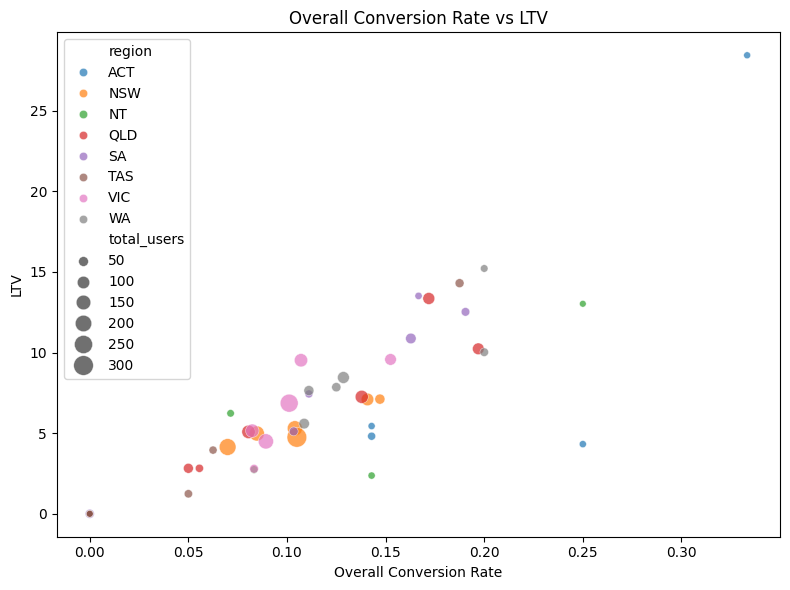

In [33]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_funnel_ltv,   
    x="overall_conversion_rate",
    y="ltv",
    hue="region",
    size="total_users",
    sizes=(20, 200),
    alpha=0.7
)

plt.title("Overall Conversion Rate vs LTV")
plt.xlabel("Overall Conversion Rate")
plt.ylabel("LTV")
plt.tight_layout()
plt.show()

##### Click-to-purchase ratio vs LTV proxy


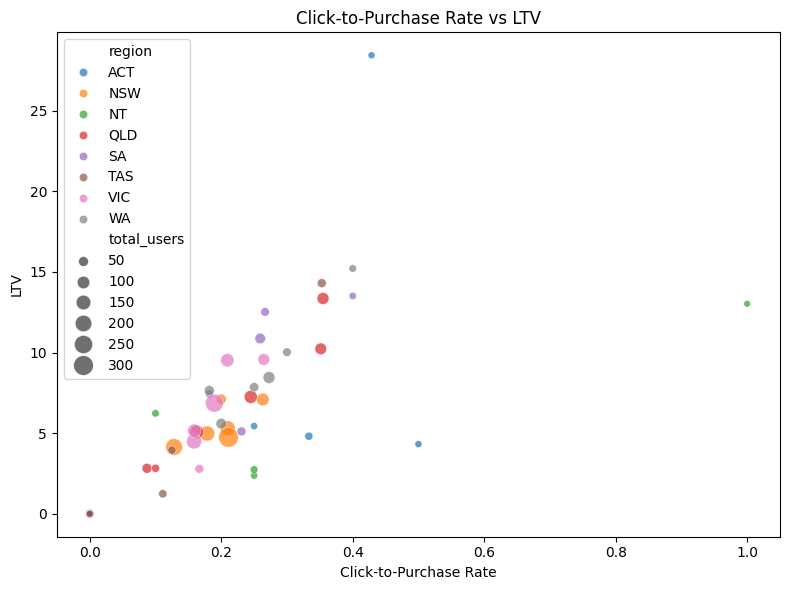

In [36]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_funnel_ltv,   
    x="click_to_purchase_rate",
    y="ltv",
    hue="region",
    size="total_users",
    sizes=(20, 200),
    alpha=0.7
)

plt.title("Click-to-Purchase Rate vs LTV")
plt.xlabel("Click-to-Purchase Rate")
plt.ylabel("LTV")
plt.tight_layout()
plt.show()

##### Correlation matrix


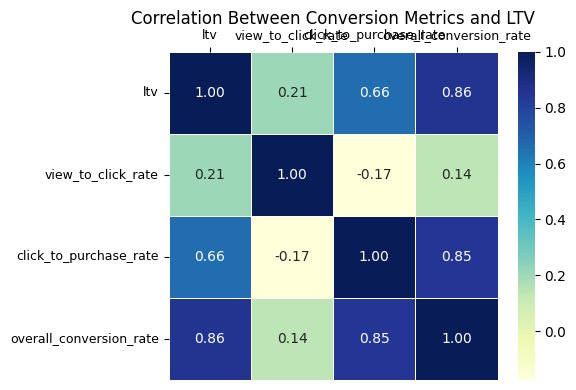

In [38]:
corr_matrix = df_funnel_ltv[
    ["ltv", "view_to_click_rate", "click_to_purchase_rate", "overall_conversion_rate"]
].corr()

plt.figure(figsize=(6, 4))

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor='white'
)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.xticks(rotation=0, fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.title("Correlation Between Conversion Metrics and LTV", pad=20)

plt.tight_layout()
plt.show()

#### Findings

- Overall conversion ratio and the LTV proxy are positively associated in this synthetic segment sample.
- Click-to-purchase ratio also has a positive sample association with the proxy.
- View-to-click ratio shows a weaker sample association.
- These statistics are partly mechanically related because paid purchases contribute both to funnel conversion and observed revenue.
- Small segment counts and synthetic generation rules limit generalisation and causal interpretation.


A stronger follow-up study would use a longer observation window, minimum segment-size rules, session-level paths, acquisition channel, and an explicit validation design.


### 5.2 High-value sample segments


The highest observed segment values include ACT 35–44, WA 65+, TAS 35–44, SA 65+, and QLD 45–54. These are **sample descriptors**, not recommended target markets. ACT 35–44, for example, contains only nine registered users in the aggregated result, so its value is especially sensitive to small-sample variation.


## 6. Summary and testable hypotheses


### 6.1 Evidence summary


- Daily click-user observations are lower than view-user observations.
- Paid-purchase-user observations form the smallest stage.
- Observed revenue per registered user varies across synthetic segments.
- Downstream conversion ratios and the revenue proxy are positively associated in this generated sample.


### 6.2 Interpretation limits


- Seven days of synthetic data cannot establish customer lifetime value, seasonality, market fit, or causal drivers.
- Segment comparisons can be unstable when user counts are small.
- No stakeholder, campaign, pricing, product, or experiment data is available to validate explanations.


### 6.3 Testable hypotheses for a real dataset


1. Investigate whether checkout-stage friction is associated with lower completion using session paths and error events.
2. Require minimum segment sizes before prioritising region or age-group differences.
3. Test acquisition or product hypotheses through controlled experiments rather than correlations alone.
4. Extend the observation window and model retention before estimating true customer lifetime value.


In [ ]:
# Release the local database connection pool after analysis.
engine.dispose()
